# KATL/KDAL V20 Binary Floor-or-Ceil Classifier

This notebook implements the exact binary task: `0 = floor(regression prediction)` and
`1 = ceil(regression prediction)`. Every honest regression prediction receives one class. There are
no boundary windows, eligibility filters, abstentions, or tuned action thresholds. The class cutoff
is fixed at 0.5.

KATL uses V20 peak-timing features and KDAL uses V20 no-peak. Hyperparameters are selected on an
inner chronological window, probabilities are Platt-calibrated on a later prior window, and the
following year is evaluated without leakage.


## Environment and source contracts


In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    raise RuntimeError("Run inside the weather-research repository")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.calibration.round_direction import (
    audit_round_direction_system,
    build_round_direction_frame,
    continuous_round_direction_comparison,
    fit_round_direction_system,
    predict_round_direction,
    round_direction_metrics,
    serializable_round_bundle,
)
from src.calibration.v19_bucket import crossfit_ridge_predictions

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

STATIONS = {
    "KATL": {
        "pipeline_dir": PROJECT_ROOT / "data/calibration/station_stacking_v20_peak_timing",
        "include_peak_features": True,
        "continuous_forward": PROJECT_ROOT / "data/calibration/station_continuous_residual_probability/KATL/KATL_forward_continuous_predictions.csv",
    },
    "KDAL": {
        "pipeline_dir": PROJECT_ROOT / "data/calibration/station_stacking_v20_kdal_no_peak",
        "include_peak_features": False,
        "continuous_forward": PROJECT_ROOT / "data/calibration/station_continuous_residual_probability/KDAL/KDAL_forward_continuous_predictions.csv",
    },
}
print(PROJECT_ROOT)


D:\dev\weather-research


## Build the all-row binary target


In [2]:
frames = {}
sources = {}
summary_rows = []
for station, config in STATIONS.items():
    pipeline = config["pipeline_dir"]
    features = pd.read_csv(pipeline / f"{station}_features.csv", low_memory=False)
    validation = pd.read_csv(pipeline / f"{station}_year_split_validation_predictions.csv")
    point = crossfit_ridge_predictions(validation)
    frame = build_round_direction_frame(
        features,
        point,
        validation,
        include_peak_features=config["include_peak_features"],
    )
    frames[station] = frame
    sources[station] = {"features": features, "validation": validation, "point": point}
    summary_rows.append(
        {
            "station": station,
            "rows": len(frame),
            "start": frame["contract_date"].min().date(),
            "end": frame["contract_date"].max().date(),
            "round_up_rate": frame["round_up"].mean(),
            "floor_ceil_change_bucket_rate": frame["floor_ceil_change_bucket"].mean(),
            "default_half_up_direction_accuracy": frame["default_half_up"].eq(frame["round_up"]).mean(),
        }
    )
dataset_summary = pd.DataFrame(summary_rows)
dataset_summary


D:\dev\weather-research\src\calibration\round_direction.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["floor_degree_f"] = floor_degree
D:\dev\weather-research\src\calibration\round_direction.py:99: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["ceil_degree_f"] = ceil_degree
D:\dev\weather-research\src\calibration\round_direction.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

,station,rows,start,end,round_up_rate,floor_ceil_change_bucket_rate,default_half_up_direction_accuracy
0,KATL,1092,2023-01-01,2025-12-31,0.463370,0.483516,0.579670
1,KDAL,1091,2023-01-01,2025-12-31,0.516957,0.468378,0.572869


### Label definition

For a non-integer prediction `p`, class `1` is correct when the integer settlement is greater than
`p`; otherwise class `0` is correct. The selected corrected degree is always exactly `ceil(p)` or
`floor(p)`. When floor and ceil map to the same 2°F bucket, the classification still exists but
cannot change the market bucket.


In [3]:
example_columns = [
    "contract_date", "point_prediction_f", "floor_degree_f", "ceil_degree_f",
    "prediction_fraction_f", "round_up", "default_half_up", "floor_bucket_label",
    "ceil_bucket_label", "floor_ceil_change_bucket", "actual_high_f",
]
pd.concat(
    [frame.assign(station=station).head(5) for station, frame in frames.items()],
    ignore_index=True,
)[["station", *example_columns]]


C:\Users\Faris Fadil Arifin\AppData\Local\Temp\ipykernel_228\4240589495.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  [frame.assign(station=station).head(5) for station, frame in frames.items()],


,station,contract_date,point_prediction_f,floor_degree_f,ceil_degree_f,prediction_fraction_f,round_up,default_half_up,floor_bucket_label,ceil_bucket_label,floor_ceil_change_bucket,actual_high_f
0,KATL,2023-01-01,67.913145,67,68,0.913145,1,1,66-67,68-69,1.0,70.0
1,KATL,2023-01-02,68.126939,68,69,0.126939,1,0,68-69,68-69,0.0,72.0
2,KATL,2023-01-03,71.071594,71,72,0.071594,0,0,70-71,72-73,1.0,70.0
3,KATL,2023-01-04,70.117850,70,71,0.117850,0,0,70-71,70-71,0.0,69.0
4,KATL,2023-01-05,61.642525,61,62,0.642525,1,1,60-61,62-63,1.0,62.0
5,KDAL,2023-01-01,76.369405,76,77,0.369405,0,0,76-77,76-77,0.0,76.0
6,KDAL,2023-01-03,67.568693,67,68,0.568693,1,1,66-67,68-69,1.0,68.0
7,KDAL,2023-01-04,59.220302,59,60,0.220302,0,0,58-59,60-61,1.0,58.0
8,KDAL,2023-01-05,59.616485,59,60,0.616485,1,1,58-59,60-61,1.0,61.0
9,KDAL,2023-01-06,69.380956,69,70,0.380956,0,0,68-69,70-71,1.0,69.0


## Chronological hyperparameter selection and probability calibration


In [4]:
results = {}
for station, config in STATIONS.items():
    print(f"Training {station}...")
    results[station] = fit_round_direction_system(
        frames[station],
        station_id=station,
        include_peak_features=config["include_peak_features"],
    )
print("Training complete")


Training KATL...


Training KDAL...


Training complete


## Selected candidates and chronological cutoffs


In [5]:
fold_states = pd.concat(
    [result["fold_states"].assign(station=station) for station, result in results.items()],
    ignore_index=True,
)
fold_states[[
    "station", "validation_year", "selected_family", "selected_params_json",
    "model_training_cutoff", "calibration_start", "calibration_cutoff",
]]


,station,validation_year,selected_family,selected_params_json,model_training_cutoff,calibration_start,calibration_cutoff
0,KATL,2024,catboost,"{""l2_regularization"": 20.0, ""learning_rate"": 0...",2023-11-01,2023-11-02,2023-12-31
1,KATL,2025,catboost,"{""l2_regularization"": 20.0, ""learning_rate"": 0...",2024-11-01,2024-11-02,2024-12-31
2,KDAL,2024,catboost,"{""l2_regularization"": 20.0, ""learning_rate"": 0...",2023-11-01,2023-11-02,2023-12-31
3,KDAL,2025,logistic,"{""C"": 0.03}",2024-11-01,2024-11-02,2024-12-31


## Honest 2024–2025 result


In [6]:
forward_metrics = pd.concat(
    [result["forward_metrics"].assign(station=station) for station, result in results.items()],
    ignore_index=True,
)
metric_columns = [
    "station", "period", "count", "round_up_rate", "binary_log_loss", "brier", "ece",
    "roc_auc", "direction_accuracy", "default_half_up_direction_accuracy",
    "point_degree_exact_accuracy", "corrected_degree_exact_accuracy",
    "point_bucket_hit_rate", "corrected_bucket_hit_rate", "bucket_hit_rate_lift",
    "actionable_count", "actionable_direction_accuracy", "bucket_switch_count",
    "recovered_losses", "damaged_wins", "net_recovered_wins", "recovery_damage_ratio",
]
forward_metrics[metric_columns]


,station,period,count,round_up_rate,binary_log_loss,brier,ece,roc_auc,direction_accuracy,default_half_up_direction_accuracy,point_degree_exact_accuracy,corrected_degree_exact_accuracy,point_bucket_hit_rate,corrected_bucket_hit_rate,bucket_hit_rate_lift,actionable_count,actionable_direction_accuracy,bucket_switch_count,recovered_losses,damaged_wins,net_recovered_wins,recovery_damage_ratio
0,KATL,2024,365,0.580822,0.890732,0.337486,0.308321,0.539863,0.419178,0.619178,0.306849,0.246575,0.493151,0.402740,-0.090411,185,0.394595,107,24,57,-33,0.421053
1,KATL,2025,364,0.489011,0.682313,0.244282,0.063410,0.601939,0.579670,0.593407,0.296703,0.280220,0.505495,0.489011,-0.016484,169,0.562130,37,13,19,-6,0.684211
2,KATL,2024-2025,729,0.534979,0.786665,0.290948,0.179525,0.505211,0.499314,0.606310,0.301783,0.263374,0.499314,0.445816,-0.053498,354,0.474576,144,37,76,-39,0.486842
3,KDAL,2024,364,0.626374,0.741194,0.272205,0.173566,0.521672,0.483516,0.560440,0.252747,0.233516,0.469780,0.447802,-0.021978,171,0.467836,62,19,27,-8,0.703704
4,KDAL,2025,364,0.549451,0.692450,0.249552,0.087006,0.588354,0.554945,0.576923,0.277473,0.266484,0.502747,0.472527,-0.030220,174,0.528736,90,33,44,-11,0.750000
5,KDAL,2024-2025,728,0.587912,0.716822,0.260878,0.109365,0.512804,0.519231,0.568681,0.265110,0.250000,0.486264,0.460165,-0.026099,345,0.498551,152,52,71,-19,0.732394


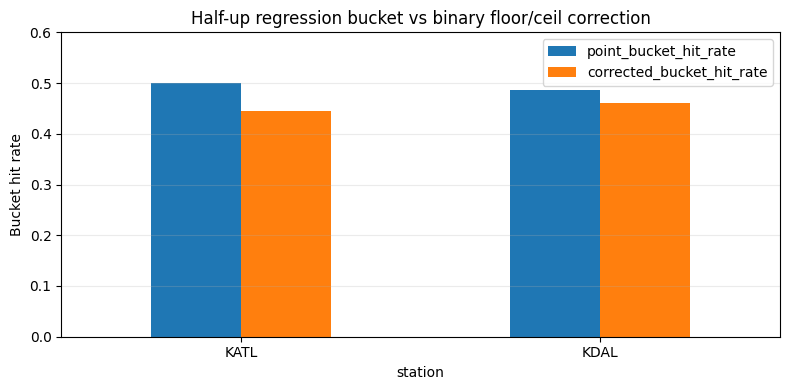

In [7]:
combined = forward_metrics.loc[forward_metrics["period"].eq("2024-2025")]
plot_data = combined.set_index("station")[["point_bucket_hit_rate", "corrected_bucket_hit_rate"]]
ax = plot_data.plot(kind="bar", figsize=(8, 4), ylim=(0, max(0.6, plot_data.to_numpy().max() + 0.05)))
ax.set_title("Half-up regression bucket vs binary floor/ceil correction")
ax.set_ylabel("Bucket hit rate")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Continuous-residual round-direction baseline


In [8]:
comparison_rows = []
for station, config in STATIONS.items():
    continuous = pd.read_csv(config["continuous_forward"])
    baseline = continuous_round_direction_comparison(
        results[station]["forward_predictions"], continuous
    ).assign(station=station, model="continuous_student_t")
    comparison_rows.append(baseline)
    selected = results[station]["forward_metrics"].loc[
        results[station]["forward_metrics"]["period"].eq("2024-2025")
    ].copy()
    selected["station"] = station
    selected["model"] = "binary_floor_ceil_classifier"
    comparison_rows.append(selected)
continuous_comparison = pd.concat(comparison_rows, ignore_index=True)
continuous_comparison[[
    "station", "model", "count", "binary_log_loss", "brier", "ece", "roc_auc",
    "direction_accuracy", "point_bucket_hit_rate", "corrected_bucket_hit_rate",
    "net_recovered_wins",
]].sort_values(["station", "binary_log_loss"])


,station,model,count,binary_log_loss,brier,ece,roc_auc,direction_accuracy,point_bucket_hit_rate,corrected_bucket_hit_rate,net_recovered_wins
0,KATL,continuous_student_t,729,0.743887,0.273051,0.149772,0.543620,0.510288,0.499314,0.433471,-48
1,KATL,binary_floor_ceil_classifier,729,0.786665,0.290948,0.179525,0.505211,0.499314,0.499314,0.445816,-39
2,KDAL,continuous_student_t,728,0.707207,0.259358,0.156745,0.573699,0.513736,0.486264,0.476648,-7
3,KDAL,binary_floor_ceil_classifier,728,0.716822,0.260878,0.109365,0.512804,0.519231,0.486264,0.460165,-19


## Exploratory 2026 result


In [9]:
holdout_predictions = {}
holdout_rows = []
for station, config in STATIONS.items():
    source = sources[station]
    test = pd.read_csv(config["pipeline_dir"] / f"{station}_year_split_test_predictions.csv")
    test_point = test.loc[
        test["method"].eq("ridge_stack"),
        ["contract_date", "actual_high_f", "predicted_high_f"],
    ]
    all_point = pd.concat(
        [source["point"][["contract_date", "actual_high_f", "predicted_high_f"]], test_point],
        ignore_index=True,
    )
    all_base = pd.concat([source["validation"], test], ignore_index=True)
    all_frame = build_round_direction_frame(
        source["features"], all_point, all_base,
        include_peak_features=config["include_peak_features"],
    )
    holdout = all_frame.loc[all_frame["year"].eq(2026)]
    predicted = predict_round_direction(results[station]["final_state"], holdout)
    holdout_predictions[station] = predicted
    holdout_rows.append({"station": station, **round_direction_metrics(predicted)})
holdout_metrics = pd.DataFrame(holdout_rows)
holdout_metrics[[
    "station", "count", "binary_log_loss", "ece", "direction_accuracy",
    "point_bucket_hit_rate", "corrected_bucket_hit_rate", "bucket_hit_rate_lift",
    "bucket_switch_count", "recovered_losses", "damaged_wins", "net_recovered_wins",
]]


D:\dev\weather-research\src\calibration\round_direction.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["floor_degree_f"] = floor_degree
D:\dev\weather-research\src\calibration\round_direction.py:99: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["ceil_degree_f"] = ceil_degree
D:\dev\weather-research\src\calibration\round_direction.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

,station,count,binary_log_loss,ece,direction_accuracy,point_bucket_hit_rate,corrected_bucket_hit_rate,bucket_hit_rate_lift,bucket_switch_count,recovered_losses,damaged_wins,net_recovered_wins
0,KATL,172,0.672360,0.052514,0.558140,0.465116,0.476744,0.011628,42,18,16,2
1,KDAL,170,0.662042,0.054822,0.582353,0.482353,0.488235,0.005882,23,8,7,1


## Executable correctness and leakage audit


In [10]:
audit_parts = []
for station, config in STATIONS.items():
    audit_parts.append(
        audit_round_direction_system(
            frames[station], results[station],
            include_peak_features=config["include_peak_features"],
        ).assign(station=station)
    )
    frame = frames[station]
    audit_parts.append(
        pd.DataFrame(
            [
                {
                    "station": station,
                    "audit": "unique_station_dates",
                    "passed": not frame["contract_date"].duplicated().any(),
                    "detail": f"duplicate_dates={int(frame['contract_date'].duplicated().sum())}",
                },
                {
                    "station": station,
                    "audit": "integer_settlement_labels",
                    "passed": bool(np.allclose(frame["actual_high_f"], np.round(frame["actual_high_f"]))),
                    "detail": f"rows={len(frame)}",
                },
                {
                    "station": station,
                    "audit": "no_boundary_window_or_abstention",
                    "passed": "nearest_boundary_distance_f" not in results[station]["feature_names"],
                    "detail": "every outer row must receive class 0 or 1",
                },
            ]
        )
    )
audit_report = pd.concat(audit_parts, ignore_index=True)[["station", "audit", "passed", "detail"]]
display(audit_report)
failed = audit_report.loc[~audit_report["passed"]]
assert failed.empty, failed.to_dict(orient="records")
print(f"All {len(audit_report)} audits passed")


,station,audit,passed,detail
0,KATL,floor_formula,True,floor(point_prediction_f)
1,KATL,ceil_formula,True,ceil(point_prediction_f)
2,KATL,binary_target_formula,True,round_up = actual_high_f > point_prediction_f
3,KATL,point_rounding_is_half_up,True,independent half-up recomputation
4,KATL,all_outer_rows_scored,True,outer_rows=729
5,KATL,fixed_binary_threshold,True,"1 when probability >= 0.5, otherwise 0"
6,KATL,corrected_degree_is_floor_or_ceil,True,no abstention or third action
7,KATL,chronological_fit_calibration_validation,True,fit < calibration < following outer year
8,KATL,policy_win_accounting_identity,True,corrected minus point wins equals recovered mi...
9,KATL,station_peak_feature_contract,True,peak_feature_overlap=29


All 28 audits passed


## Export research artifacts


In [11]:
OUTPUT_ROOT = PROJECT_ROOT / "data/calibration/station_round_direction_classifier"
export_rows = []
for station, result in results.items():
    output = OUTPUT_ROOT / station
    weights = output / "model_weights"
    weights.mkdir(parents=True, exist_ok=True)
    result["forward_predictions"].to_csv(output / f"{station}_forward_round_predictions.csv", index=False)
    result["forward_metrics"].to_csv(output / f"{station}_forward_round_metrics.csv", index=False)
    result["fold_states"].to_csv(output / f"{station}_round_fold_states.csv", index=False)
    result["tuning"].to_csv(output / f"{station}_round_inner_tuning.csv", index=False)
    holdout_predictions[station].to_csv(output / f"{station}_2026_round_predictions.csv", index=False)
    bundle_path = weights / f"{station}_floor_ceil_classifier_v1.joblib"
    joblib.dump(serializable_round_bundle(result), bundle_path)
    export_rows.append(
        {
            "station": station,
            "bundle": str(bundle_path),
            "selected_family": result["final_state"]["selected_spec"].family,
            "class_threshold": 0.5,
        }
    )
audit_report.to_csv(OUTPUT_ROOT / "round_direction_audit.csv", index=False)
dataset_summary.to_csv(OUTPUT_ROOT / "dataset_summary.csv", index=False)
continuous_comparison.to_csv(OUTPUT_ROOT / "continuous_baseline_comparison.csv", index=False)
holdout_metrics.to_csv(OUTPUT_ROOT / "exploratory_2026_metrics.csv", index=False)
pd.DataFrame(export_rows)


,station,bundle,selected_family,class_threshold
0,KATL,D:\dev\weather-research\data\calibration\stati...,catboost,0.5
1,KDAL,D:\dev\weather-research\data\calibration\stati...,catboost,0.5


## Decision rule

The model always emits one binary action: probability at least 0.5 selects `ceil`, otherwise
`floor`. Deployment requires a positive honest bucket-hit lift and net recovered wins versus the
existing half-up regression. The exploratory 2026 section cannot override the 2024–2025 result.
